# Analyse reactivation impact

In [36]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import geopandas as gpd
from shapely import geometry
#import contextily as cx
import matplotlib.pyplot as plt
from quetzal.model import stepmodel
from quetzal.io import excel
from syspy.skims import skims

## Scenario settings

In [2]:
# Choose scenarios
scenario_ref = 'reference'
scenarios = [scenario_ref] + ['Reactivation', 'Shift', 'Reactivation+Shift']

In [3]:
input_path = '../input/'
network_path = '../input_static/'
output_path = '../output/'
model_path = '../model/'
params = excel.read_var(file='../input/parameters.xls', scenario=scenario_ref)
segments = [s.strip() for s in params['general']['demand_segments'].split(';')]
purposes = [s.split('_')[0] for s in segments][::2]

In [11]:
# Load model zones
ref = stepmodel.read_json(model_path + scenario_ref + '/de_zones')
ref.zones = gpd.GeoDataFrame(ref.zones, crs=ref.epsg)

In [12]:
# All regions near reactivated railway line
all_zone_ids = [int(i) for i in '10010000;10020000;10040000;10510011;10530032;10530100;10535323;10535358;10545489;10550028;10560048;10560049;10565690;10570001;10570008;10570091;10575727;10575755;10575782;10575785;10580034;10580135;10585833;10590183;10595952;10605005;10610113;10615138;10615179;10615189;20000000;31010000;31020000;31510040;31515402;31515406;31540019;31540028;31550003;31550013;31570008;32520001;32520005;32555408;32555409;32559502;32570028;32570031;32570035;32575401;32575404;32575405;33510004;33510006;33510026;33530040;33535401;33535402;33535405;33535406;33545406;33550001;33550009;33550022;33555401;33555405;33555406;33555407;33560007;33560011;33570008;33570016;33570039;33575403;33575404;33575405;33575406;33575408;33580002;33580024;33590038;33595402;33595406;33610003;33610005;33610012;34040000;34520001;34520019;34520023;34520027;34525403;34560001;34560015;34565401;34565402;34590004;34590005;34610007;34625401;40120000;51120000;51140000;51160000;51190000;51200000;51240000;51540024;51540036;51540040;51540048;51540056;51580012;51580028;51580032;51580036;51620016;51620020;51620024;51660036;51700008;51700024;51700028;51700032;51700044;51700048;51700052;53140000;53150000;53340002;53340004;53340008;53340012;53340032;53340036;53580004;53580024;53580036;53620004;53620016;53620040;53660020;53660024;53660036;53700020;53700036;53700040;53740004;53740008;53740012;53740016;53740024;53740028;53740032;53740040;53740044;53740048;53740052;53780004;53780024;53780032;53820012;53820028;53820044;53820056;53820060;53820068;55150000;55540008;55540012;55540016;55540020;55540048;55540064;55580012;55580040;55660016;55660028;55660040;55660044;55660048;55660056;55660060;55660076;55660084;55660088;55660092;55700004;55700008;55700020;55700040;55700048;57540008;57540016;57540044;57540048;57660012;57660024;57660044;57740012;57740016;57740024;57740032;57740036;59540008;59540012;59540016;59540024;59540028;59580004;59580012;59580044;59620016;59620040;59660008;59660024;59740004;59740016;59740028;59740044;64110000;64120000;64140000;64320004;64320008;64320009;64320011;64320019;64320020;64320023;64330011;64340004;64350001;64350027;64350029;64359200;64380009;64390001;64390002;64390006;64390015;64400024;65310001;65310008;65310010;65310013;65310015;65310017;65310018;65320003;65320005;65320006;65320009;65320018;65320021;65320022;65330008;65330017;65330018;65340001;65340003;65340011;65340013;65340018;65340020;65350005;65350009;66110000;66320009;66320010;66320016;66320020;66330003;66330012;66330015;66330017;66330020;66330023;66340004;66340009;66340011;66340013;66340014;66340022;66360006;66369200;71110000;71315001;71315002;71325010;71335010;71335011;71345002;71355002;71355003;71370068;71370203;71375002;71375008;71385003;71385005;71405004;71405008;71415003;71415011;71435003;71435005;71435007;71435010;72110000;72335001;72335004;72335006;72355001;72355003;72355006;72355007;73130000;73315003;73325007;73335003;73335004;73335006;73340007;73345001;73345005;73365008;73375004;73375007;73395008;73405001;73405002;73405004;81110000;81150041;81150050;81150052;81155001;81160077;81160078;81165001;81165008;81170010;81175003;81175004;81175005;81175008;81175009;81175011;81180003;81180011;81180021;81180046;81180048;81180050;81180051;81180060;81180076;81180080;81185002;81185005;81185006;81185007;81185008;81190061;81195001;81195005;81210000;81255002;81255003;81255005;81255006;81255010;81255012;81255014;81265001;81265003;81265004;81270008;81275004;81350015;81365007;82110000;82120000;82150064;82150084;82150102;82155003;82165005;82165006;82210000;82220000;82255002;82255003;82255005;82255006;82260062;82260063;82260084;82260105;82265008;82265009;82355002;82355006;82375003;83155002;83170057;83170153;83255003;83355005;83355006;83360014;83360091;83365001;83365003;83365007;83365008;83370106;83370116;83375005;84150059;84150061;84150092;84155001;84165003;84170025;84175001;84175002;84175004;84175006;84255009;84360008;84365001;84370086;84375002;84375003;84375004;84375006;91710127;91720116;91720117;91720124;91720132;91729454;91760114;91760137;91770115;91770137;91770139;91810113;91810128;91810130;91815138;91815139;91815142;91830128;91835149;91835152;91870113;91870116;91870124;91870128;91870176;91870182;91875162;91895170;91900148;91905174;92610000;92620000;92720118;92720141;92720151;92725214;92730137;92735216;92735217;92740113;92740172;92740176;92745221;92750128;92750135;92750144;92750146;92750151;92755229;92770121;92790115;92790126;93730112;93730146;93730147;93735321;93750196;93755337;93760119;93760141;93760170;93770154;93770158;93775347;93775351;94630000;94730120;94730141;94730159;94750112;94750156;94755428;94760152;95630000;95640000;95710136;95710145;95710193;95710200;95710214;95715501;95715502;95715508;95770136;96610000;96620000;96710122;96720113;96720163;96720166;96725606;96729457;96729458;96729466;96730117;96750141;96750158;96755614;96755615;96755619;96770155;96775624;96780135;96780138;96785642;96795645;96795647;97720131;97720141;97720167;97725708;97725709;97780116;97780137;97780169;97785760;97785764;97790147;97790194;97795720;97795721;100410100;100410512;100410515;100410517;100410519;100420112;100420113;100420116;100430111;100440111;100440112;100440113;100440116;100440117;100440119;100440120;100450112;100450114;100460114;100460115;110000000;120600269;120600280;120610219;120610260;120610316;120610320;120610332;120610540;120620224;120625031;120630148;120630208;120630252;120630357;120640029;120640227;120640317;120640336;120640512;120645403;120645414;120650096;120650136;120650144;120650165;120650193;120650225;120650251;120650256;120660304;120665607;120670036;120670426;120675707;120680468;120690017;120690304;120690590;120690596;120690604;120690665;120695918;120700424;120705001;120705005;120705006;120710160;120720017;120720120;120720340;120720477;130030000;130715154;130715155;130715159;130720043;130725255;130725256;130725257;130725260;130730105;130735352;130735355;130755553;130755562;130760108;130765654;130765655;130765663;130765666;130765667;145110000;145210390;145210495;145220080;145220260;145220460;145220480;145220510;145220540;145225126;145230010;145230160;145230200;145230310;145230365;145235131;145245114;146250030;146250250;146260245;146260280;146260390;146260530;146270080;146270100;146270140;146270180;147130000;147290080;147290150;147290160;147300020;147300080;147300110;147300160;147305601;150030000;150820430;150840355;150845051;150845054;150860005;150860040;150860055;150860140;150870275;150870370;150870412;150875051;150875052;150880205;150880305;150880330;150890026;150910020;150910160;150910375;160540000;160620041;160630078;160630082;160630097;160630101;160630103;160635051;160650087;160655055;160670029;160675050;160675052;160675054;160680051;160680058;160680063;160685009;160690012;160690043;160695002;160700029;160700057;160705002;160715051;160720011;160725051;160730077;160735005;160750062;160750098;160750134;160750135;160750136;160755004;160755011;160755013;160755050;160760092'.split(';')]

## Plotting settings

In [13]:
# Plot fonts
import matplotlib
#matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'arial'

In [14]:
# Resolution of output plots
dpi = 500

In [15]:
# Define the mode colors
cmap_mode = plt.get_cmap('CMRmap')
colormap = {'car':cmap_mode(.45), 'private_car':cmap_mode(.45), 'car_sharing':cmap_mode(.51),
            'rail':cmap_mode(.24), 'rail_long':cmap_mode(.31), 'rail_short':cmap_mode(.24),
            'coach':cmap_mode(.82), 'bus':cmap_mode(.72),
            'air':cmap_mode(.02), 'air_domestic':cmap_mode(.02),
            'non-motorised':'lightgray'#cmap_mode(.92)
           } # also defines mode order

In [16]:
# Colors and linestyles for each scenario (max four scenarios)
colors = {s: c for s,c in zip(scenarios, ['blue', 'purple', 'red', 'orange'][:len(scenarios)])}
linestyles = {s: l for s,l in zip(scenarios, ['-', ':', '--', '-.'][:len(scenarios)])}

# Load data

* CC
* Trips
* Mode share PT
* pkm

only inter-zonal

In [17]:
# Choose a radius for OD analysis
radius = 50000
destinations = ref.zones.loc[ref.zones['geometry'].to_crs(3857).centroid.within(
    ref.zones.loc[all_zone_ids, 'geometry'].to_crs(3857).union_all().buffer(radius))].index

In [18]:
# Load distances
distances = pd.read_csv(output_path + '/distances_centroids.csv')
distances = distances.loc[(distances['origin'].isin(all_zone_ids)) & (distances['destination'].isin(destinations))]
distances = distances.set_index(['origin', 'destination']).sort_index()

In [19]:
# Load CC
cc = {}
for scenario in scenarios:
    df = pd.read_csv(output_path + scenario + '/mode_choice_od_composite_cost.csv')
    df = df.loc[(df['origin'].isin(all_zone_ids)) & (df['destination'].isin(destinations))]
    cc[scenario] = df.set_index(['origin', 'destination']).sort_index()

In [20]:
# Trips/volumes
vols = {}
for scenario in scenarios:
    distr = stepmodel.read_zippedpickles(model_path + scenario + '/de_volumes_distribution')
    if len(set(segments) - set(distr.volumes.columns)) == 0:
        vols[scenario] = distr.volumes
    else:
        choice = stepmodel.read_zippedpickles(model_path + scenario + '/de_volumes_choice')
        vols[scenario] = pd.merge(choice.volumes, distr.volumes, how='outer', on=['origin', 'destination']).reset_index(drop=True)
        del choice
    del distr
    vols[scenario] = vols[scenario].loc[(vols[scenario]['origin'].isin(all_zone_ids))
                                        & (vols[scenario]['destination'].isin(destinations))
                                        & (vols[scenario]['origin']!=vols[scenario]['destination'])]
    vols[scenario] = vols[scenario].set_index(['origin', 'destination']).sort_index()

volumes: 100%|███████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.91it/s]


In [21]:
# LoS table for short-distance PT
mode = ['rail_short', 'bus']
los = {}
for scenario in scenarios:
    sm = stepmodel.read_zippedpickles(model_path + scenario + '/de_logit')
    sm.volumes = vols[scenario].reset_index()
    sm.los = sm.pt_los
    sm.los[['origin', 'destination']] = sm.los[['origin', 'destination']].astype(int)
    sm.compute_los_volume(keep_segments=False)
    sm.pt_los = sm.los
    los[scenario] = sm.pt_los.loc[(sm.pt_los['origin'].isin(all_zone_ids))
                                   & (sm.pt_los['destination'].isin(destinations))
                                   & (sm.pt_los['route_type'].isin(mode))]
    del sm

utility_values: 100%|████████████████████████████████████████████████████████████████████| 9/9 [00:10<00:00,  1.15s/it]


In [22]:
# pkm
pkm = {}
for s in scenarios:
    pkm[s] = los[s].groupby(['origin', 'route_type']).apply(lambda g: (g['volume'] * g['length']/1000).sum()).unstack('route_type').sum(axis=1)

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_26440\1168367476.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pkm[s] = los[s].groupby(['origin', 'route_type']).apply(lambda g: (g['volume'] * g['length']/1000).sum()).unstack('route_type').sum(axis=1)
C:\Users\m.arnz\AppData\Local\Temp\ipykernel_26440\1168367476.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pkm[s] = los[s].groupby(['origin', 'route_

In [23]:
# Load reactivation projectsr
reac_links = gpd.read_file(network_path + 'de_rail_reactivation/links.geojson')
reac_links.index = ['rs_reac_'+str(i) for i in range(len(reac_links))]
reac_nodes = gpd.read_file(network_path + 'de_rail_reactivation/nodes.geojson')
reac_nodes = reac_nodes.set_crs(ref.epsg)
# Map zones to reactivated lines
reac_nodes['zone'] = 0
for ind, zone in ref.zones.iterrows():
    reac_nodes.loc[reac_nodes['geometry'].within(zone['geometry']), 'zone'] = ind
reac_nodes['zone'] = reac_nodes['zone'].fillna(0).astype(int)

# Correlations

mode shift potential (mode share change compared between reference and reactivation) in correlation with:

Origin-zone attributes
* population
* pop. density
* pkm

OD relations
* CC
* number of trips
* travel time

Only reactivated OD pairs
* reactivated railway length
* number of reactivated stops
* stop-length ratio

Only inter-zonal!

In [24]:
# Select scenarios
scen1 = scenarios[0]
scen2 = scenarios[1]

# Imputate reactivation details
reac_links_set = set(reac_links.index)
los[scen2]['reac_links'] = los[scen2]['link_path'].apply(lambda l: set(l).intersection(reac_links_set))
los[scen2]['is_reactivated'] = los[scen2]['reac_links'].apply(lambda l: len(l) > 0)
los[scen2]['reac_reasons'] = [set() for _ in range(len(los[scen2]))]
reac_reasons_dict = reac_links['agency_id'].replace({'A,C,I': 'A;C;I'}).apply(lambda s: s.split(';')).to_dict()
los[scen2].loc[los[scen2]['is_reactivated'], 'reac_reasons'] = \
    los[scen2].loc[los[scen2]['is_reactivated'], 'reac_links'].apply(
        lambda s: set(sum([reac_reasons_dict[l] for l in s
                           if l in reac_reasons_dict.keys()
                           and reac_reasons_dict[l]!=['n.n.']
                          ], []) ))

# Create modal shift potential between scenarios for each OD pair
merged = los[scen1].merge(
    los[scen2], how='outer', on=['origin', 'destination', 'route_types'], suffixes=[scen1, scen2])
merged = merged.set_index(['origin', 'destination'])
merged[['volume'+scen1, 'volume'+scen2]] = merged[['volume'+scen1, 'volume'+scen2]].fillna(0)
merged['is_reactivated'] = merged['is_reactivated'].fillna(False)
merged['time'+scen1] = merged['time'+scen1].fillna(merged['time'+scen2] * 1.1)
merged.loc[merged['reac_reasons'].isna(), 'reac_reasons'] = [set() for _ in merged.loc[merged['reac_reasons'].isna()].index]
merged = merged.groupby(level=[0,1]).agg(
    {'volume'+scen1: 'sum', 'volume'+scen2: 'sum',
     'time'+scen1: 'min', 'time'+scen2: 'min',
     'is_reactivated': 'max', 'reac_reasons': list, 'reac_links': list})
merged['reac_reasons'] = merged['reac_reasons'].apply(lambda l: set.union(*l))

C:\Users\m.arnz\AppData\Local\Temp\ipykernel_26440\1743179785.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged['is_reactivated'] = merged['is_reactivated'].fillna(False)


In [25]:
merged['is_reactivated'].value_counts()

is_reactivated
False    19964
True      8492
Name: count, dtype: int64

In [26]:
# Generate data cols for OD relations
# Single most important reason for reactivation: Choose the first
merged['reac_reason'] = merged['reac_reasons'].apply(lambda s: sorted(list(s))[0] if len(s)>0 else '')
# Compute volume shares
result_col = 'Mode shift towards local PT'
merged['volume_all'+scen1] = vols[scen1].sum(axis=1)
merged['volume_all'+scen2] = vols[scen2].sum(axis=1)
merged[result_col] = (merged['volume'+scen2] / merged['volume_all'+scen2]) - (merged['volume'+scen1] / merged['volume_all'+scen1])
# Time difference
time_col = 'Minimum OD travel time difference [hours]'
merged[time_col] = merged['time'+scen2] - merged['time'+scen1]
# Volume difference
vol_col = 'Total number of trips difference'
merged[vol_col] = merged['volume_all'+scen2] - merged['volume_all'+scen1]
# CC diff
cc_col = 'Volume-weighted composite cost difference [-]'
cc_scen1 = cc[scen1].multiply(vols[scen1]).mean(axis=1).dropna()
cc_scen2 = cc[scen2].multiply(vols[scen2]).mean(axis=1).dropna()
merged[cc_col] = (cc_scen2 - cc_scen1)
merged[cc_col] = (merged[cc_col]-merged[cc_col].mean())/merged[cc_col].std()

is_reactivated
False    Axes(0.125,0.11;0.775x0.77)
True     Axes(0.125,0.11;0.775x0.77)
Name: Mode shift towards local PT, dtype: object

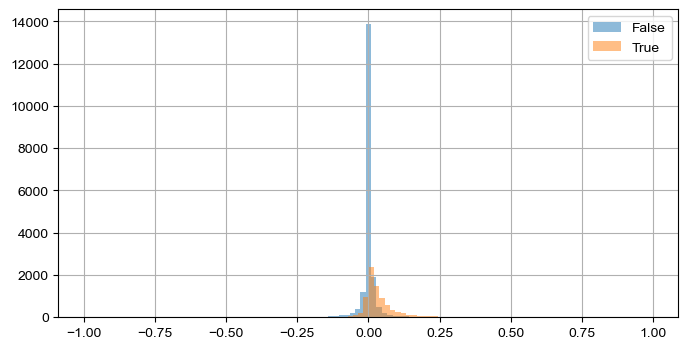

In [27]:
merged.groupby('is_reactivated')[result_col].hist(bins=100, figsize=(8,4), alpha=.5, legend=True)

In [28]:
# Generate data cols for origin zone attributes
pop_col = 'Population (thousands, logarithmic)'
merged[pop_col] = merged.index.get_level_values('origin').map(ref.zones['population']) / 1e3
popdens_col = 'Population density (logarithmic) [cap/km²]'
merged[popdens_col] = merged.index.get_level_values('origin').map(ref.zones['population'] / ref.zones['area'])
pkm_col = 'Pkm per capita by local PT in '+scen1
merged[pkm_col] = merged.index.get_level_values('origin').map(pkm[scen1] / ref.zones['population'])

In [29]:
# Generate data cols for reactivated line properties
reac_links['zone_a'] = reac_links['a'].map(reac_nodes.set_index('index')['zone'])
reac_links['zone_b'] = reac_links['b'].map(reac_nodes.set_index('index')['zone'])
reac_trips = reac_links.groupby('trip_id').agg({'length': 'sum', 'a': 'count', 'zone_a': set, 'zone_b': set})
reac_trips['zones'] = [list(set.union(*z)) for z in zip(reac_trips['zone_a'], reac_trips['zone_b'])]
reac_trips['length'] = reac_trips['length'] / 1000
reac_trips['stops'] = reac_trips['a'] + 1
reac_trips['stops_length'] = reac_trips['stops'] / reac_trips['length']
reac_od = reac_links.groupby(['zone_a', 'zone_b'])['trip_id'].apply(lambda t: list(set(t)))
reac_od = reac_od.reset_index().explode('trip_id')
reac_od['length'] = reac_od['trip_id'].map(reac_trips['length'])
reac_od['stops'] = reac_od['trip_id'].map(reac_trips['stops'])
reac_od['stops_length'] = reac_od['trip_id'].map(reac_trips['stops_length'])
reac_od = reac_od.groupby(['zone_a', 'zone_b']).agg({'length':'sum', 'stops': 'sum', 'stops_length': 'mean'})
reac_od.index.names = ['origin', 'destination']
merged = merged.merge(reac_od, how='left', left_index=True, right_index=True)
length_col = 'Length of reactivated rail line(s)'
stops_col = 'Number of stops in reactivated rail line(s)'
stoplength_col = 'Stops-length ratio of reactivated rail line(s)'
merged.rename(columns={'stops':stops_col, 'length':length_col, 'stops_length':stoplength_col}, inplace=True)

In [30]:
merged['is_reactivated_really'] = merged['is_reactivated'] & merged[length_col].notna()
merged['is_reactivated_really'].value_counts()

is_reactivated_really
False    28133
True       323
Name: count, dtype: int64

In [83]:
def plot_scatter(ax, x, y, logx=False, colour_col='reac_reason', marker_col='reac_reason', legend=True, only_reac=True, fit=False):
    df = merged.loc[merged[[x,y]].notna().all(axis=1)].copy()
    if only_reac:
        df = df.loc[df['is_reactivated_really']]
        df = df.loc[df[marker_col]!='']
    df = df.sort_values(colour_col)
    
    # Determine colors
    colour_labels = df[colour_col].unique()
    cmap = plt.get_cmap('rainbow', len(colour_labels))
    colours = [matplotlib.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]
    colour_mapping = {item:i for item,i in zip(colour_labels, colours)}
    df['colour_col'] = df[colour_col].apply(lambda x: colour_mapping[x])
    alpha = (len(df)-len(df)/2)/len(df)
    # Determine marker styles
    marker_labels = sorted(list(df[marker_col].unique()))
    markers = ['*', 'o', 'x', 'p', '+', 's', 'v', '^', '<', '>', 'h'][:len(marker_labels)]
    df['marker_col'] = df[marker_col].map(dict(zip(marker_labels, markers)))

    # Plot
    for i,marker in enumerate(markers):
        df_1 = df.loc[df['marker_col']==marker]
        ax.scatter(df_1[x], df_1[y], alpha=alpha, c=df_1['colour_col'], marker=marker, label=marker_labels[i])
        if fit:
            try:
                def fit_func(x, a, b):
                    return a + b * x
                popt, pcov = curve_fit(fit_func, df_1[x], df_1[y])
                ax.plot(df_1[x], fit_func(df_1[x], *popt), alpha=alpha, c=df_1['colour_col'].iloc[0], linestyle='--')
            except TypeError:
                pass
    if logx: ax.set_xscale('log')
    # Annotation
    ax.set_ylabel(y)
    ax.set_xlabel(x)
    ax.set_ylim(-0.03, 0.21)
    if legend: ax.legend()
    
    return ax

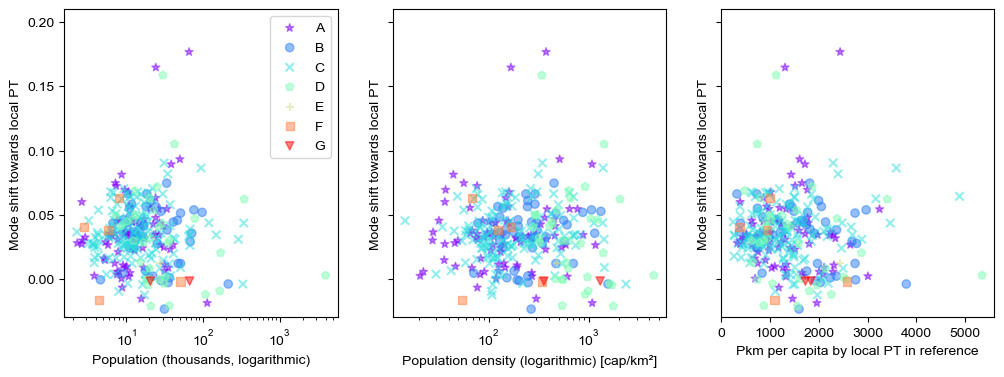

In [84]:
# Origin attributes
fig, axs = plt.subplots(1,3, figsize=(12,4), sharey='all')
plot_scatter(axs[0], y=result_col, x=pop_col, logx=True, legend=True, only_reac=True)
plot_scatter(axs[1], y=result_col, x=popdens_col, logx=True, legend=False, only_reac=True)
plot_scatter(axs[2], y=result_col, x=pkm_col, legend=False, only_reac=True)
plt.savefig(output_path + '_reactivation_analysis/correlation_scatter_origin_attributes.png', dpi=dpi, bbox_inches='tight')

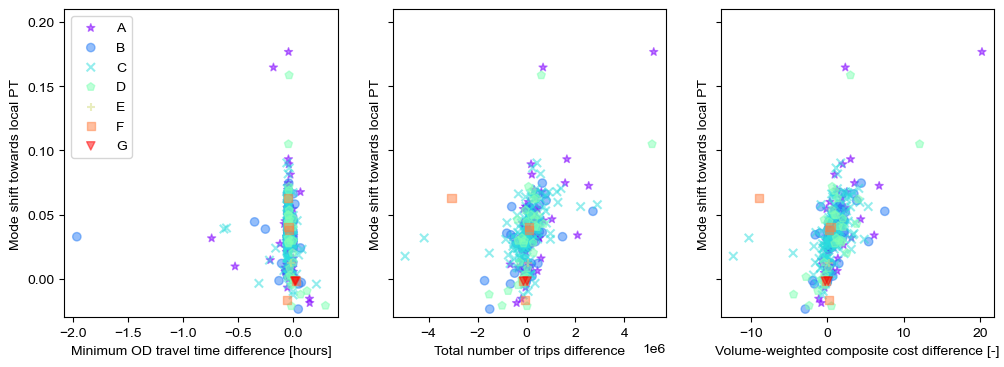

In [85]:
# OD attributes
fig, axs = plt.subplots(1,3, figsize=(12,4), sharey='all')
plot_scatter(axs[0], y=result_col, x=time_col, legend=True, only_reac=True)
plot_scatter(axs[1], y=result_col, x=vol_col, legend=False, only_reac=True)
plot_scatter(axs[2], y=result_col, x=cc_col, legend=False, only_reac=True)
plt.savefig(output_path + '_reactivation_analysis/correlation_scatter_OD_attributes.png', dpi=dpi, bbox_inches='tight')

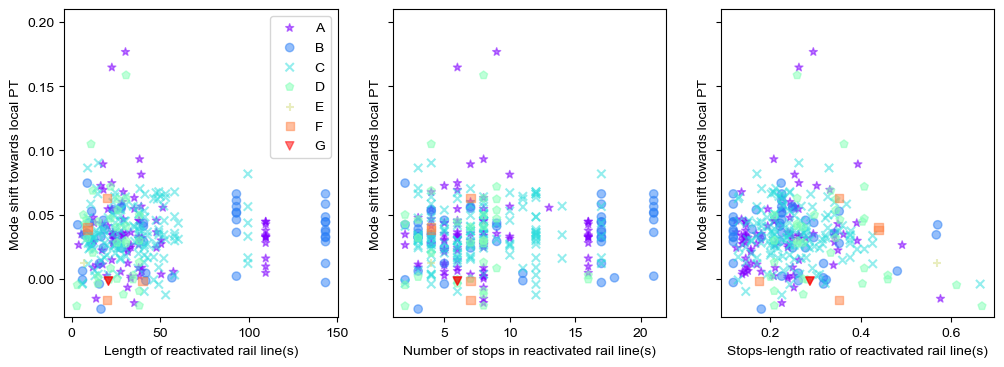

In [86]:
# OD attributes of reactivated railway lines
fig, axs = plt.subplots(1,3, figsize=(12,4), sharey='all')
plot_scatter(axs[0], y=result_col, x=length_col, legend=True, only_reac=True)
plot_scatter(axs[1], y=result_col, x=stops_col, legend=False, only_reac=True)
plot_scatter(axs[2], y=result_col, x=stoplength_col, legend=False, only_reac=True)
plt.savefig(output_path + '_reactivation_analysis/correlation_scatter_line_attributes.png', dpi=dpi, bbox_inches='tight')

In [68]:
merged.loc[merged['is_reactivated_really'], result_col].describe()

count    323.000000
mean       0.035484
std        0.032252
min       -0.023576
25%        0.019828
50%        0.033615
75%        0.046268
max        0.362865
Name: Mode shift towards local PT, dtype: float64

<Axes: >

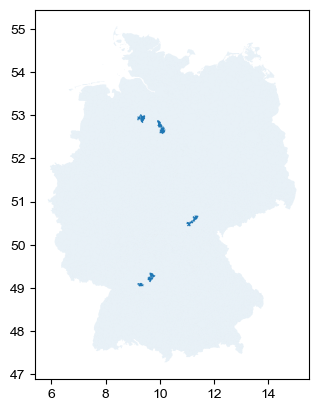

In [95]:
# Zones with maximum mode shift
max_od = merged.loc[(merged['is_reactivated_really']) & (merged[result_col]>=0.15)].index
ref.zones.loc[sum([list(od) for od in max_od], [])].plot(ax=ref.zones.plot(alpha=.1))

array([[<Axes: title={'center': 'Population (thousands, logarithmic)'}>,
        <Axes: title={'center': 'Population density (logarithmic) [cap/km²]'}>],
       [<Axes: title={'center': 'Pkm per capita by local PT in reference'}>,
        <Axes: >]], dtype=object)

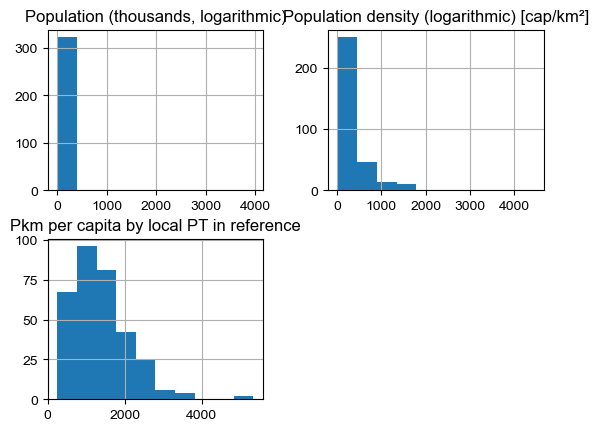

In [35]:
merged.loc[merged['is_reactivated_really'], [pop_col, popdens_col, pkm_col]].hist()

# Regression model

test significance for each reactivation reason

In [64]:
cols = [pop_col, popdens_col, pkm_col, time_col, vol_col, cc_col, length_col, stops_col, stoplength_col]
def regress(reac_reason=None):
    data = merged.loc[merged['is_reactivated_really']].copy()
    data[[pop_col, popdens_col]] = data[[pop_col, popdens_col]].apply(lambda x: np.log(x), axis=1)
    data = data.loc[data[cols+[result_col]].notna().all(axis=1)]
    if reac_reason:
        data = data.loc[data['reac_reason']==reac_reason]
    y = data[result_col]
    X = data[cols]
    # Normalise
    scaler = StandardScaler()
    X_ = scaler.fit_transform(X)
    if len(X_) >= 12:
        # Split in test and train data
        X_train, X_test, y_train, y_test = train_test_split(X_, y, test_size=0.2, random_state=42)
        # Regression
        model = LinearRegression()
        model.fit(X_train, y_train)
        # Metrics
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
    
        return \
            len(y_test),  len(y_train), \
            mae, mse, r2, \
            model.intercept_, *model.coef_
    else:
        return 0,  len(y), *[np.nan]*(len(cols)+4)

In [65]:
regression = pd.DataFrame(columns=['N test data', 'N training data', 'MAE', 'MSE', 'R^2', 'intercept']+cols)
regression.loc['All projects'] = regress()
reasons = list('ABCDEFG')
for r in reasons:
    regression.loc[r] = regress(r)
regression

,N test data,N training data,MAE,MSE,R^2,intercept,"Population (thousands, logarithmic)",Population density (logarithmic) [cap/km²],Pkm per capita by local PT in reference,Minimum OD travel time difference [hours],Total number of trips difference,Volume-weighted composite cost difference [-],Length of reactivated rail line(s),Number of stops in reactivated rail line(s),Stops-length ratio of reactivated rail line(s)
All projects,65.0,258.0,0.017000,0.000543,0.046646,0.036476,-0.000671,-0.000466,-0.000813,-0.006909,-0.000758,0.013256,-0.009562,0.008291,-0.001493
A,17.0,68.0,0.020770,0.001148,0.188240,0.033616,0.001272,-0.001468,-0.004064,-0.001650,0.004406,0.015728,-0.018651,0.016956,-0.003983
B,10.0,37.0,0.020597,0.000618,0.134543,0.036858,-0.006756,0.009320,-0.003860,0.003187,0.003102,0.005869,-0.004798,0.001258,-0.005485
C,29.0,112.0,0.018355,0.000556,-0.791195,0.040174,-0.004638,0.006911,0.009555,0.001851,0.001146,0.006117,-0.019173,0.014753,-0.009948
D,7.0,27.0,0.038726,0.002900,-0.083565,0.026407,0.001046,0.009206,-0.016508,-0.006118,-0.008407,0.021209,-0.035191,0.030837,-0.019748
E,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
F,0.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
